In [ ]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, "..")

from bayesoptax.surrogates.gp import predict
from bayesoptax.surrogates.inference import fit

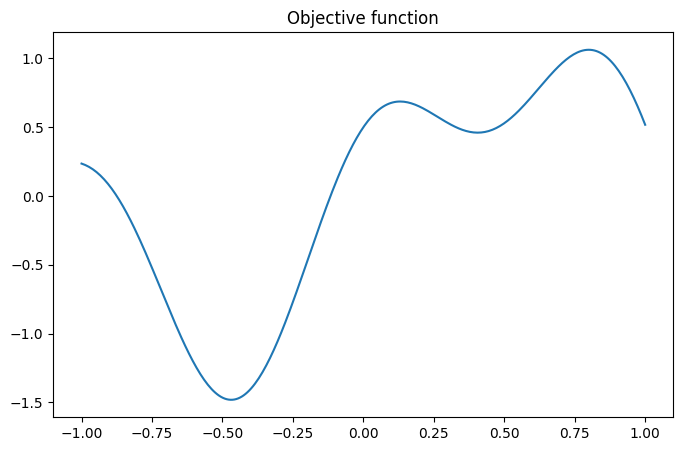

In [2]:
def f(x):
    return jnp.sin(3 * x[0]) + 0.5 * jnp.cos(7 * x[0])

X_test = jnp.linspace(-1., 1., 300)[:, None]
y_test = jax.vmap(f)(X_test)

plt.figure(figsize=(8, 5))
plt.plot(X_test, y_test)
plt.title('Objective function')
plt.show()

In [3]:
N_train = 10

key = jr.PRNGKey(0)

X_train = jr.uniform(key, shape=(N_train, 1), minval=-0.8, maxval=0.8)
y_train = jax.vmap(f)(X_train)

key, subkey = jr.split(key)
y_train = y_train + 0.05 * jr.normal(subkey, shape=(N_train,))

y_mean = y_train.mean()
y_std = y_train.std() + 1e-8
y_norm = (y_train - y_mean) / y_std

In [4]:
KERNEL="rbf"
fitted_params = fit(X_train, y_norm, kernel_name=KERNEL, key=key)
mean, var = predict(fitted_params, X_train, y_train, X_test, kernel_name=KERNEL)

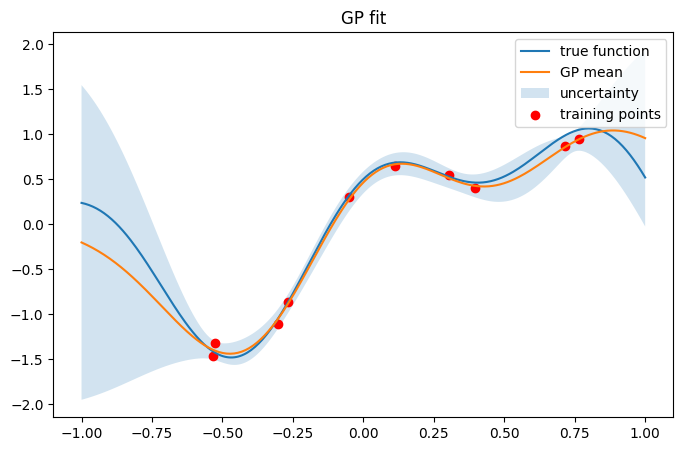

In [5]:
x_plot = X_test[:, 0]

plt.figure(figsize=(8, 5))
plt.plot(x_plot, y_test, label="true function")
plt.plot(x_plot, mean, label="GP mean")
plt.fill_between(
    x_plot,
    mean - 2 * jnp.sqrt(var),
    mean + 2 * jnp.sqrt(var),
    alpha=0.2,
    label="uncertainty"
)
plt.scatter(X_train[:, 0], y_train, color="red", label="training points")
plt.title("GP fit")
plt.legend(loc='upper right')
plt.show()